# Quiz Destination — Prototype V1

**Objectif** : inférer un profil psychographique voyageur en 5-7 questions, puis recommander les 3 villes les plus proches via similarité cosinus.

**Problème résolu** (cf. note de cadrage §1) :
- Le quiz actuel est **additif** (briques séparées vs personnalité cohérente)
- Il est **déclaratif** (biais de désirabilité : tout le monde coche « culture » et « aventure »)
- Il est **plat** (la question N+1 ne dépend jamais de la réponse N)

**Architecture V1** (cf. note §4 — « Commencer simple ») :
- Villes et utilisateur placés dans le **même espace psychographique** à 6 dimensions (§6)
- Questions organisées en **blocs thématiques** (2-3 items par axe) qui triangulent chaque dimension (§4)
- Agrégation par bloc avec **détection de contradictions intra-bloc** (§4)
- Format **arbitrage forcé / MaxDiff** + **scénarios projectifs** (§5)
- Matching = **plus proches voisins** (similarité cosinus)
- **Pas de routage adaptatif pour la V1** — les blocs se déroulent dans l'ordre (§4, mise en garde)

In [1]:
import numpy as np
import pandas as pd
from IPython.display import display, clear_output
import ipywidgets as widgets

print("✅ Librairies chargées")

✅ Librairies chargées


## 1. Les 6 axes psychographiques (cf. note §3)

Cadres de référence : **Plog** (psychocentrique ↔ allocentrique), **Big Five / OCEAN** (ouverture à l'expérience), **Push/Pull theory**.

| Axe | 0 (pôle gauche) | 1 (pôle droit) |
|-----|-----------------|----------------|
| `nouveaute` | Familiarité, rassurant | Dépaysement, inconnu |
| `action` | Ressourcement, lenteur | Exploration, rythme intense |
| `culture` | Hédonisme, plaisir | Patrimoine, profondeur |
| `urbain` | Nature, calme | Animation urbaine |
| `authenticite` | Confort, standing | Immersion locale |
| `structure` | Tout planifié, structuré | Improvisation, spontanéité |

> **Avantage** (§3) : ces axes sont en grande partie dérivables des POI (densité musées / restaurants / vie nocturne / espaces verts).

In [2]:
AXES = ["nouveaute", "action", "culture", "urbain", "authenticite", "structure"]

AXES_LABELS = {
    "nouveaute":    ("Familiarité",     "Dépaysement"),
    "action":       ("Ressourcement",   "Exploration"),
    "culture":      ("Hédonisme",       "Culture/profondeur"),
    "urbain":       ("Nature/calme",    "Animation urbaine"),
    "authenticite": ("Confort/standing", "Authenticité locale"),
    "structure":    ("Tout planifié",   "Spontanéité"),
}

print("Axes définis :", AXES)

Axes définis : ['nouveaute', 'action', 'culture', 'urbain', 'authenticite', 'structure']


## 2. Scoring des villes (10 villes européennes, scoring manuel v1)

Chaque valeur est entre 0 et 1 sur chaque axe. Ce scoring sera affiné plus tard via les POI ou les trips réels (cf. note §6, §8).

> **Note** : Le scoring `structure` reflète à quel point la ville se prête à l'improvisation (1) vs nécessite de la planification (0). Ex : Reykjavik demande de la logistique, Paris se visite facilement au feeling.

In [3]:
#  VECTEURS VILLES  (scoring manuel v1)
#  Axes : nouveaute | action | culture | urbain | authenticite | structure
VILLES = {
    #                 nouv  act   cult  urb   auth  struct
    "Lisbonne":   [0.70, 0.60, 0.75, 0.75, 0.85, 0.80],
    "Ibiza":      [0.45, 0.90, 0.20, 0.65, 0.30, 0.70],
    "Prague":     [0.60, 0.65, 0.80, 0.80, 0.60, 0.65],
    "Reykjavik":  [0.90, 0.75, 0.55, 0.30, 0.70, 0.25],
    "Paris":      [0.40, 0.55, 0.95, 0.90, 0.50, 0.75],
    "Séville":    [0.65, 0.65, 0.80, 0.70, 0.80, 0.80],
    "Amsterdam":  [0.55, 0.70, 0.75, 0.85, 0.55, 0.70],
    "Dubrovnik":  [0.60, 0.60, 0.65, 0.55, 0.65, 0.55],
    "Berlin":     [0.70, 0.85, 0.65, 0.90, 0.60, 0.85],
    "Santorini":  [0.50, 0.35, 0.45, 0.40, 0.40, 0.50],
}

df_villes = pd.DataFrame(VILLES, index=AXES).T
print("Scoring des villes (0 = pôle gauche, 1 = pôle droit)\n")
print(df_villes.round(2).to_string())

Scoring des villes (0 = pôle gauche, 1 = pôle droit)

           nouveaute  action  culture  urbain  authenticite  structure
Lisbonne        0.70    0.60     0.75    0.75          0.85       0.80
Ibiza           0.45    0.90     0.20    0.65          0.30       0.70
Prague          0.60    0.65     0.80    0.80          0.60       0.65
Reykjavik       0.90    0.75     0.55    0.30          0.70       0.25
Paris           0.40    0.55     0.95    0.90          0.50       0.75
Séville         0.65    0.65     0.80    0.70          0.80       0.80
Amsterdam       0.55    0.70     0.75    0.85          0.55       0.70
Dubrovnik       0.60    0.60     0.65    0.55          0.65       0.55
Berlin          0.70    0.85     0.65    0.90          0.60       0.85
Santorini       0.50    0.35     0.45    0.40          0.40       0.50


## 3. Banque de questions — organisée en blocs thématiques (cf. note §4-5)

**Principes appliqués :**
- **6 blocs**, un par axe psychographique — chaque bloc est l'instrument de mesure de son axe
- **2-3 items par bloc** qui triangulent la même dimension (cf. §4 : « on ne mesure jamais un trait avec une seule question »)
- Format **arbitrage forcé / MaxDiff** : deux options opposées, pas d'échelle (cf. §5 : « ça tue le biais tout-le-monde-dit-oui »)
- **Scénarios projectifs** inclus (cf. §5 : « C'est le jour 3, tu as un après-midi libre... »)
- Chaque item contribue principalement à **1 axe** (son bloc), avec parfois une contribution secondaire légère

**Pourquoi 2-3 items par bloc ?** (§4)
- Une question isolée est bruitée (humeur, interprétation, contexte)
- La combinaison de 2-3 items donne une coordonnée fiable
- Si deux items se contredisent → le signal est incertain (détecté par le moteur)

In [4]:
# ─────────────────────────────────────────────
#  BANQUE DE QUESTIONS — 6 blocs, 2-3 items par bloc
#  Chaque bloc triangule un axe psychographique.
#  Format : arbitrage forcé (MaxDiff) + scénarios projectifs
# ─────────────────────────────────────────────
QUESTIONS = [
    # ── BLOC 1 : Nouveauté ↔ Familiarité ─────────────────────────────
    {
        "id": "nouv_1",
        "bloc": "Nouveauté",
        "axe_principal": "nouveaute",
        "texte": "Pour les restos, tu préfères :",
        "option_A": "⭐ Un établissement réputé, fiable, bien noté",
        "option_B": "🍜 Un boui-boui local sans touristes, même si c'est incertain",
        "contributions": {
            "nouveaute":    {"A": 0.15, "B": 0.90, "force": 0.9},
        },
    },
    {
        "id": "nouv_2",
        "bloc": "Nouveauté",
        "axe_principal": "nouveaute",
        "texte": "Tu dois choisir ta prochaine destination :",
        "option_A": "🔄 Un pays que tu connais déjà et que tu adores",
        "option_B": "🌍 Un endroit dont tu ne sais presque rien",
        "contributions": {
            "nouveaute":    {"A": 0.10, "B": 0.95, "force": 0.9},
        },
    },

    # ── BLOC 2 : Action ↔ Ressourcement ──────────────────────────────
    {
        "id": "act_1",
        "bloc": "Rythme",
        "axe_principal": "action",
        "texte": "Ton idéal pour une journée libre en voyage :",
        "option_A": "🧘 Flemmarder dans un café, laisser venir",
        "option_B": "🗺️ Partir à l'aventure, enchaîner les découvertes",
        "contributions": {
            "action":       {"A": 0.10, "B": 0.90, "force": 0.9},
        },
    },
    {
        "id": "act_2",
        "bloc": "Rythme",
        "axe_principal": "action",
        "texte": "Tu rentres d'un voyage épuisé, tu te dis :",
        "option_A": "😩 J'aurais dû lever le pied, j'ai trop couru",
        "option_B": "😄 C'était intense, exactement ce que je voulais",
        "contributions": {
            "action":       {"A": 0.15, "B": 0.85, "force": 0.85},
        },
    },

    # ── BLOC 3 : Culture/profondeur ↔ Hédonisme ──────────────────────
    {
        "id": "cult_1",
        "bloc": "Culture",
        "axe_principal": "culture",
        "texte": "Ta demi-journée idéale :",
        "option_A": "🍹 Terrasse au soleil, apéro, bonne musique",
        "option_B": "🏛️ Un grand musée ou un site historique exceptionnel",
        "contributions": {
            "culture":      {"A": 0.10, "B": 0.90, "force": 0.9},
        },
    },
    {
        "id": "cult_2",
        "bloc": "Culture",
        "axe_principal": "culture",
        "texte": "Le voyage parfait te laisse avec :",
        "option_A": "😎 Des souvenirs de fête, de bonne bouffe, de pur plaisir",
        "option_B": "📚 Des connaissances, des histoires, de la profondeur",
        "contributions": {
            "culture":      {"A": 0.15, "B": 0.85, "force": 0.85},
        },
    },

    # ── BLOC 4 : Animation urbaine ↔ Nature/calme ────────────────────
    {
        "id": "urb_1",
        "bloc": "Environnement",
        "axe_principal": "urbain",
        "texte": "Tu te ressources mieux :",
        "option_A": "🌿 Dans la nature, le calme, loin de l'agitation",
        "option_B": "🏙️ En plein cœur d'une ville vivante et animée",
        "contributions": {
            "urbain":       {"A": 0.10, "B": 0.90, "force": 1.0},
        },
    },
    {
        "id": "urb_2",
        "bloc": "Environnement",
        "axe_principal": "urbain",
        "texte": "C'est le jour 3, il fait beau, tu as un après-midi libre :",
        "option_A": "🥾 Tu files en dehors de la ville — rando, plage ou lac",
        "option_B": "🚶 Tu te perds dans les rues, les marchés, la vie locale",
        "contributions": {
            "urbain":       {"A": 0.15, "B": 0.85, "force": 0.85},
        },
    },

    # ── BLOC 5 : Authenticité locale ↔ Confort/standing ──────────────
    {
        "id": "auth_1",
        "bloc": "Confort",
        "axe_principal": "authenticite",
        "texte": "Pour l'hébergement, tu penches vers :",
        "option_A": "🏨 Hôtel confortable, propre, sans surprise",
        "option_B": "🏠 Chez l'habitant ou Airbnb dans un quartier local",
        "contributions": {
            "authenticite": {"A": 0.15, "B": 0.90, "force": 0.9},
        },
    },
    {
        "id": "auth_2",
        "bloc": "Confort",
        "axe_principal": "authenticite",
        "texte": "Tu arrives dans une nouvelle ville, pour dîner tu :",
        "option_A": "📱 Cherches le resto le mieux noté sur Google Maps",
        "option_B": "👀 Suis les locaux et rentres dans le premier endroit bondé",
        "contributions": {
            "authenticite": {"A": 0.15, "B": 0.85, "force": 0.85},
        },
    },

    # ── BLOC 6 : Structure ↔ Spontanéité ─────────────────────────────
    {
        "id": "struct_1",
        "bloc": "Planification",
        "axe_principal": "structure",
        "texte": "Avant de partir en voyage, tu as tendance à :",
        "option_A": "📋 Tout réserver à l'avance : vols, hôtels, visites",
        "option_B": "✈️ Booker le vol et voir sur place",
        "contributions": {
            "structure":    {"A": 0.10, "B": 0.90, "force": 0.9},
        },
    },
    {
        "id": "struct_2",
        "bloc": "Planification",
        "axe_principal": "structure",
        "texte": "Ton programme change en cours de route :",
        "option_A": "😤 Ça te stresse, tu préfères suivre le plan",
        "option_B": "🤩 Tant mieux, les meilleurs moments sont imprévus",
        "contributions": {
            "structure":    {"A": 0.15, "B": 0.85, "force": 0.85},
        },
    },
]

# Construire l'index des blocs
BLOCS = {}
for q in QUESTIONS:
    BLOCS.setdefault(q["bloc"], []).append(q)

print(f"✅ {len(QUESTIONS)} questions chargées dans {len(BLOCS)} blocs :")
for bloc, qs in BLOCS.items():
    axe = qs[0]["axe_principal"]
    print(f"   {bloc:15s} → axe '{axe}' ({len(qs)} items)")

✅ 12 questions chargées dans 6 blocs :
   Nouveauté       → axe 'nouveaute' (2 items)
   Rythme          → axe 'action' (2 items)
   Culture         → axe 'culture' (2 items)
   Environnement   → axe 'urbain' (2 items)
   Confort         → axe 'authenticite' (2 items)
   Planification   → axe 'structure' (2 items)


## 4. Le moteur V1 — blocs séquentiels avec agrégation (cf. note §4)

**Logique V1 (« commencer simple ») :**
1. On démarre avec un vecteur utilisateur neutre `[0.5] * 6`
2. On déroule les blocs **dans l'ordre**, sans routage adaptatif
3. À l'intérieur de chaque bloc, les réponses s'agrègent en un **sous-score**
4. Si deux items d'un même bloc se contredisent → **signal incertain** (confiance réduite)
5. La confiance finale par axe dépend à la fois du nombre d'items et de leur cohérence

> **Pour la V2** (cf. note §4) : le routage intelligent (sauter / pondérer des blocs selon la confiance acquise) sera ajouté une fois les blocs et le scoring validés sur de la vraie donnée.

In [5]:
class QuizBlocsV1:
    """Moteur V1 : blocs séquentiels, agrégation par bloc, détection de contradictions."""

    SEUIL_CONTRADICTION = 0.5

    def __init__(self, blocs, axes):
        self.blocs       = blocs
        self.axes        = axes
        self.ordre_blocs = list(blocs.keys())
        self.reset()

    def reset(self):
        self.vecteur      = {axe: 0.5 for axe in self.axes}
        self.poids_total  = {axe: 0.0 for axe in self.axes}
        self.historique    = []
        self.contradictions = {}
        self._bloc_idx    = 0
        self._q_idx       = 0

    # ── Prochaine question (séquentiel) ───────────────────────────────
    def prochaine_question(self):
        while self._bloc_idx < len(self.ordre_blocs):
            bloc_nom = self.ordre_blocs[self._bloc_idx]
            questions_bloc = self.blocs[bloc_nom]
            if self._q_idx < len(questions_bloc):
                return questions_bloc[self._q_idx]
            self._bloc_idx += 1
            self._q_idx = 0
        return None

    # ── Mise à jour du vecteur après une réponse ──────────────────────
    def mettre_a_jour(self, question, choix):
        for axe, params in question["contributions"].items():
            valeur_cible = params[choix]
            force        = params["force"]
            w_ancien  = self.poids_total[axe]
            w_nouveau = force
            self.vecteur[axe] = (
                (self.vecteur[axe] * w_ancien + valeur_cible * w_nouveau)
                / (w_ancien + w_nouveau)
            )
            self.poids_total[axe] += w_nouveau

        self.historique.append({
            "question": question["id"],
            "bloc": question["bloc"],
            "choix": choix,
        })
        self._q_idx += 1
        self._detecter_contradictions(question["bloc"])

    # ── Détection de contradictions intra-bloc (cf. note §4) ──────────
    def _detecter_contradictions(self, bloc_nom):
        reponses_bloc = [h for h in self.historique if h["bloc"] == bloc_nom]
        if len(reponses_bloc) < 2:
            return

        questions_bloc = self.blocs[bloc_nom]
        axe = questions_bloc[0]["axe_principal"]
        valeurs = []
        for rep in reponses_bloc:
            q = next(q for q in questions_bloc if q["id"] == rep["question"])
            if axe in q["contributions"]:
                valeurs.append(q["contributions"][axe][rep["choix"]])

        if len(valeurs) >= 2:
            ecart = max(valeurs) - min(valeurs)
            if ecart >= self.SEUIL_CONTRADICTION:
                self.contradictions[bloc_nom] = {
                    "axe": axe,
                    "ecart": ecart,
                    "valeurs": valeurs,
                }

    # ── Confiance par axe ─────────────────────────────────────────────
    def confiance(self):
        conf = {}
        for axe in self.axes:
            base = min(self.poids_total[axe] / 1.8, 1.0)
            for bloc_nom, contradiction in self.contradictions.items():
                if contradiction["axe"] == axe:
                    penalite = contradiction["ecart"] * 0.4
                    base = max(0.0, base - penalite)
            conf[axe] = base
        return conf

    # ── Bloc courant ──────────────────────────────────────────────────
    def bloc_courant(self):
        if self._bloc_idx < len(self.ordre_blocs):
            return self.ordre_blocs[self._bloc_idx]
        return None

    def progression(self):
        total = sum(len(qs) for qs in self.blocs.values())
        fait = len(self.historique)
        return fait, total

    # ── Affichage de l'état courant ───────────────────────────────────
    def afficher_etat(self):
        conf = self.confiance()
        print("\n📊 Vecteur utilisateur courant :")
        for axe in self.axes:
            barre = "█" * int(self.vecteur[axe] * 20)
            flag = " ⚠️" if any(
                c["axe"] == axe for c in self.contradictions.values()
            ) else ""
            print(f"  {axe:15s} {self.vecteur[axe]:.2f}  {barre:<20s}  (confiance: {conf[axe]:.0%}){flag}")

        if self.contradictions:
            print("\n⚠️  Contradictions détectées :")
            for bloc, info in self.contradictions.items():
                print(f"   Bloc '{bloc}' (axe {info['axe']}) — écart {info['ecart']:.2f} entre les réponses")

print("✅ Moteur V1 par blocs défini")

✅ Moteur V1 par blocs défini


## 5. Le matching par similarité cosinus (cf. note §6)

L'idée structurante : l'utilisateur ET les destinations vivent dans le **même espace à 6 dimensions**. La recommandation = plus proches voisins (similarité cosinus).

> « On n'a plus besoin que l'utilisateur coche explicitement "j'aime la nouveauté" — on l'infère de ses réponses, et on peut pondérer chaque dimension. » (§6)

In [6]:
# ─────────────────────────────────────────────
#  MATCHING
# ─────────────────────────────────────────────

def similarite_cosinus(vec_a, vec_b):
    a = np.array(vec_a)
    b = np.array(vec_b)
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

def recommander(vecteur_utilisateur, villes, axes, top_n=3):
    vec_u = [vecteur_utilisateur[axe] for axe in axes]
    scores = {}
    for ville, vec_v in villes.items():
        scores[ville] = similarite_cosinus(vec_u, vec_v)
    classement = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return classement[:top_n], scores

def afficher_recommandations(top3, scores, vecteur_utilisateur, axes):
    medailles = ["🥇", "🥈", "🥉"]
    print("\n" + "═" * 50)
    print("  🌍 VOS 3 DESTINATIONS RECOMMANDÉES")
    print("═" * 50)
    for i, (ville, score) in enumerate(top3):
        print(f"\n  {medailles[i]} {ville}  (score : {score:.3f})")
        # Explication : axes où l'utilisateur et la ville se ressemblent le plus
        vecteur_ville = dict(zip(axes, VILLES[ville]))
        proximites = {
            axe: 1 - abs(vecteur_utilisateur[axe] - vecteur_ville[axe])
            for axe in axes
        }
        points_forts = sorted(proximites.items(), key=lambda x: x[1], reverse=True)[:2]
        for axe, prox in points_forts:
            label_gauche, label_droit = AXES_LABELS[axe]
            val_u = vecteur_utilisateur[axe]
            tendance = label_droit if val_u > 0.5 else label_gauche
            print(f"     → Aligné sur '{tendance}' ({axe})")
    print("\n" + "═" * 50)

print("✅ Fonctions de matching définies")

✅ Fonctions de matching définies


## 6. Simulation automatique (sans interaction)

Teste le quiz V1 avec des profils prédéfinis pour vérifier la mécanique par blocs.
Chaque profil donne 12 réponses (2 par bloc × 6 blocs).

In [7]:
# ─────────────────────────────────────────────
#  SIMULATION : 3 profils + 1 profil contradictoire
#  12 réponses par profil (2 items × 6 blocs)
#  Ordre des blocs : Nouveauté, Rythme, Culture, Environnement, Confort, Planification
# ─────────────────────────────────────────────

profils_test = {
    "Aventurier authentique":  "BB BB BA BB BB BB",
    "Hédoniste urbain":        "AA AA AB BB AA BB",
    "Culturel contemplatif":   "AB AA BB BA BA AA",
    "Contradictoire (test)":   "AB BA AB BA AB BA",
}

for nom_profil, reponses_str in profils_test.items():
    print(f"\n{'━'*60}")
    print(f"  PROFIL : {nom_profil}")
    print(f"{'━'*60}")

    quiz = QuizBlocsV1(BLOCS, AXES)
    reponses = [c for c in reponses_str if c in ("A", "B")]

    i = 0
    while True:
        question = quiz.prochaine_question()
        if not question:
            break
        choix = reponses[i] if i < len(reponses) else "A"
        bloc = question["bloc"]
        texte_choix = question[f"option_{choix}"]
        fait, total = quiz.progression()
        print(f"  Q{fait+1:2d}/{total} [{bloc:15s}] {question['texte']}")
        print(f"       → {choix} : {texte_choix}")
        quiz.mettre_a_jour(question, choix)
        i += 1

    quiz.afficher_etat()
    top3, scores = recommander(quiz.vecteur, VILLES, AXES)
    afficher_recommandations(top3, scores, quiz.vecteur, AXES)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PROFIL : Aventurier authentique
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Q 1/12 [Nouveauté      ] Pour les restos, tu préfères :
       → B : 🍜 Un boui-boui local sans touristes, même si c'est incertain
  Q 2/12 [Nouveauté      ] Tu dois choisir ta prochaine destination :
       → B : 🌍 Un endroit dont tu ne sais presque rien
  Q 3/12 [Rythme         ] Ton idéal pour une journée libre en voyage :
       → B : 🗺️ Partir à l'aventure, enchaîner les découvertes
  Q 4/12 [Rythme         ] Tu rentres d'un voyage épuisé, tu te dis :
       → B : 😄 C'était intense, exactement ce que je voulais
  Q 5/12 [Culture        ] Ta demi-journée idéale :
       → B : 🏛️ Un grand musée ou un site historique exceptionnel
  Q 6/12 [Culture        ] Le voyage parfait te laisse avec :
       → A : 😎 Des souvenirs de fête, de bonne bouffe, de pur plaisir
  Q 7/12 [Environnement  ] Tu te ressources mieux :
       → B : 🏙️ En

## 7. Quiz interactif V1 (à lancer dans Jupyter)

Lance la cellule ci-dessous pour jouer le quiz. Les blocs se déroulent dans l'ordre, 2 questions par bloc.

In [8]:
quiz = QuizBlocsV1(BLOCS, AXES)

output   = widgets.Output()
btn_A    = widgets.Button(description="", layout=widgets.Layout(width="45%", height="60px"),
                          style={"button_color": "#e8f4fd"})
btn_B    = widgets.Button(description="", layout=widgets.Layout(width="45%", height="60px"),
                          style={"button_color": "#fde8f4"})
fait, total = quiz.progression()
progress = widgets.IntProgress(value=0, min=0, max=total,
                                description="Avancement :", bar_style="info")
lbl_bloc = widgets.HTML(value="")
box_btns = widgets.HBox([btn_A, btn_B], layout=widgets.Layout(justify_content="space-around"))

def afficher_question():
    q = quiz.prochaine_question()
    fait, total = quiz.progression()
    with output:
        clear_output(wait=True)
        if q is None:
            btn_A.layout.display = "none"
            btn_B.layout.display = "none"
            lbl_bloc.value = ""
            top3, scores = recommander(quiz.vecteur, VILLES, AXES)
            afficher_recommandations(top3, scores, quiz.vecteur, AXES)
            quiz.afficher_etat()
        else:
            lbl_bloc.value = f"<b>Bloc : {q['bloc']}</b> (axe : {q['axe_principal']})"
            print(f"\n  Question {fait+1} / {total}")
            print(f"  ❓ {q['texte']}\n")
            btn_A.description = q["option_A"]
            btn_B.description = q["option_B"]
            btn_A.layout.display = ""
            btn_B.layout.display = ""

def on_choix(choix):
    q = quiz.prochaine_question()
    if q:
        quiz.mettre_a_jour(q, choix)
        fait, _ = quiz.progression()
        progress.value = fait
        afficher_question()

btn_A.on_click(lambda b: on_choix("A"))
btn_B.on_click(lambda b: on_choix("B"))

display(progress, lbl_bloc, box_btns, output)
afficher_question()

IntProgress(value=0, bar_style='info', description='Avancement :', max=12)

HTML(value='')

Output()

## 8. Visualisation du scoring des villes (6 axes)

Radar chart pour comparer visuellement les profils des villes sur les 6 dimensions.

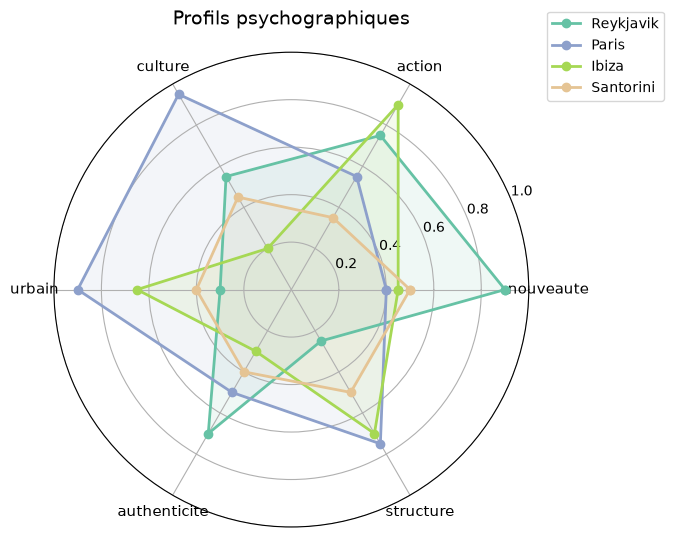

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def radar_chart(villes_selectionnees, villes_data, axes, vecteur_user=None):
    N = len(axes)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # fermer le polygone

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    colors = plt.cm.Set2(np.linspace(0, 1, len(villes_selectionnees) + 1))

    for i, ville in enumerate(villes_selectionnees):
        values = villes_data[ville] + [villes_data[ville][0]]
        ax.plot(angles, values, "o-", linewidth=2, color=colors[i], label=ville)
        ax.fill(angles, values, alpha=0.1, color=colors[i])

    if vecteur_user:
        values_u = [vecteur_user[axe] for axe in axes] + [vecteur_user[axes[0]]]
        ax.plot(angles, values_u, "o-", linewidth=2.5, color="red",
                linestyle="--", label="Vous")
        ax.fill(angles, values_u, alpha=0.05, color="red")

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(axes, size=11)
    ax.set_ylim(0, 1)
    ax.set_title("Profils psychographiques", size=14, pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()

# Comparer quelques villes contrastées
radar_chart(
    ["Reykjavik", "Paris", "Ibiza", "Santorini"],
    VILLES, AXES
)

## 9. Prochaines étapes (cf. note §9-10)

### V1 — Valider la grille (étapes 1-5 de la note §10)
- [x] **Figer les 6 axes** psychographiques
- [x] **Scorer 10 villes à la main** sur ces axes
- [x] **Découper en blocs** et rattacher chaque axe à 2 items (mécaniques MaxDiff + projectifs)
- [x] **Prototyper le matching** (vecteur utilisateur → similarité cosinus → top 3)
- [ ] **Tester sur des profils internes**, puis confronter aux trips réels (3 500 utilisateurs, ~9 000 trips — cf. §8)

### V1+ — Affiner
- [ ] **Ajuster le scoring des villes** — affiner via les POI (densité musées / restos / vie nocturne / espaces verts) ou LLM en batch (§6)
- [ ] **Ajouter les 40 villes restantes** — à partir des données existantes
- [ ] **Calibrer les seuils** — ajuster le seuil de contradiction (0.5) et le plafond de confiance (1.8) selon les données réelles
- [ ] **A/B tester les blocs de questions** — comparer différentes formulations
- [ ] **Ajouter un 3ème item par bloc** pour les axes à faible confiance

### V2 — Routage adaptatif (cf. note §4, §5)
- [ ] **Routage inter-blocs** : sauter un bloc si la confiance est déjà forte, réinvestir le budget question ailleurs
- [ ] **Branchement adaptatif** : la question suivante dépend des précédentes
- [ ] **Préférence visuelle** : montrer des images, faire choisir (§5)
- [ ] **Transposer en JS** — une fois la grille validée, réimplémenter dans l'app